In [1]:
import tensorflow as tf
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models

In [2]:
from google.colab import files
uploaded = files.upload()

zip_path = "Wonders of World.zip"
extract_to = "/content/landmarks_data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extraction complete!")

Saving Wonders of World.zip to Wonders of World (1).zip
Extraction complete!


In [15]:
import os

for root, dirs, files in os.walk(extract_to):
    level = root.replace(extract_to, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

/
Wonders of World/
  .DS_Store
  machu_pichu/
    cae4d50c73.jpg
    8782f34d89.jpg
    3a0e7bc077.jpg
    6c788b5e1c.jpg
    7d1f20c68d.jpg
    031c03b290.jpg
    a9bda860bd.jpg
    881208244a.jpg
    ad8e3dd6dc.jpg
    ce84579b56.jpg
    727135e558.jpg
    2c90888905.jpg
    70e3cdbda0.jpg
    3161e2566b.jpg
    1fda85f359.jpg
    18bd952a90.jpg
    fc0dbc61e5.jpg
    2b6c20dd95.jpg
    6ab682d37f.jpg
    984040817b.jpg
    124eddce09.jpg
    0436c6db7f.jpg
    55b53957ad.jpg
    7c5b0f4854.jpg
    59c4a5c4a2.jpg
    def19a66fb.jpg
    fde4966127.jpg
    55bb791a24.jpg
    2d78ee964a.jpg
    681a61c0e0.jpg
    127fbb6f8f.jpg
    45ba029dc0.jpg
    3a0d8f457b.jpg
    adfaa23579.jpg
    515abfa2d4.jpg
    52dc63c4d9.jpg
    f616fbccd0.jpg
    0b36ea4e3e.jpg
    55e1ac18b0.jpg
    53836133b3.jpg
    45c472c314.jpg
    7056c00d2c.jpg
    cc8d126051.jpg
    7c33837b3d.jpg
    801c45715b.jpg
    3c0111aa59.jpg
    840c61306f.jpg
    d0084cc128.jpg
    592dd3ff43.jpg
    45a806381d.jpg
   

In [19]:
import shutil

macosx_folder = "/content/landmarks_data/__MACOSX"

shutil.rmtree(macosx_folder, ignore_errors=True)
print(" Removed __MACOSX folder.")

 Removed __MACOSX folder.


In [40]:
import os

folder_path = '/content/landmarks_data/Wonders of World'

os.listdir(folder_path)

['machu_pichu',
 'eiffel_tower',
 'burj_khalifa',
 'chichen_itza',
 'pyramids_of_giza',
 'stonehenge',
 'taj_mahal',
 'statue_of_liberty',
 'venezuela_angel_falls',
 'roman_colosseum',
 '.DS_Store',
 'great_wall_of_china',
 'christ_the_reedemer']

In [31]:
import os
import shutil

source_dir = "/content/landmarks_data/Wonders of World"

destination_root = "/content/landmarks_data"

for filename in os.listdir(source_dir):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):

        name_part = filename.split('_')[0].strip().title()

        class_folder = os.path.join(destination_root, name_part)
        os.makedirs(class_folder, exist_ok=True)

        src = os.path.join(source_dir, filename)
        dst = os.path.join(class_folder, filename)
        shutil.move(src, dst)

print("Images organized into folders by guessed class.")

Images organized into folders by guessed class.


In [41]:
import os

dataset_directory = '/content/landmarks_data/'

for root, dirs, files in os.walk(dataset_directory):
    print(f"Current root: {root}")
    print(f"Subfolders (classes): {dirs}")
    print(f"Files: {files}")
    print("-" * 50)

Current root: /content/landmarks_data/
Subfolders (classes): ['__MACOSX', 'Wonders of World']
Files: []
--------------------------------------------------
Current root: /content/landmarks_data/__MACOSX
Subfolders (classes): ['Wonders of World']
Files: ['._Wonders of World']
--------------------------------------------------
Current root: /content/landmarks_data/__MACOSX/Wonders of World
Subfolders (classes): ['machu_pichu', 'eiffel_tower', 'burj_khalifa', 'chichen_itza', 'pyramids_of_giza', 'stonehenge', 'taj_mahal', 'statue_of_liberty', 'venezuela_angel_falls', 'roman_colosseum', 'great_wall_of_china', 'christ_the_reedemer']
Files: ['._christ_the_reedemer', '._stonehenge', '._burj_khalifa', '._great_wall_of_china', '._roman_colosseum', '._machu_pichu', '._pyramids_of_giza', '._taj_mahal', '._statue_of_liberty', '._chichen_itza', '._.DS_Store', '._venezuela_angel_falls', '._eiffel_tower']
--------------------------------------------------
Current root: /content/landmarks_data/__MACOSX/

In [44]:
import shutil
import os

def remove_mac_folder(directory):
    for root, dirs, files in os.walk(directory):
        if '__MACOSX' in dirs:
            mac_folder_path = os.path.join(root, '__MACOSX')
            shutil.rmtree(mac_folder_path)
            print(f"Removed folder: {mac_folder_path}")

remove_mac_folder('/content/landmarks_data')

Removed folder: /content/landmarks_data/__MACOSX


In [46]:
import os
import shutil

parent_dir = '/content/landmarks_data/Wonders of World'

for class_folder in os.listdir(parent_dir):
    class_path = os.path.join(parent_dir, class_folder)

    if os.path.isdir(class_path):
        shutil.move(class_path, os.path.join('/content/landmarks_data/', class_folder))

shutil.rmtree(parent_dir)

subfolders = [f for f in os.listdir('/content/landmarks_data') if os.path.isdir(os.path.join('/content/landmarks_data', f))]
print(f"Subfolders: {subfolders}")

Subfolders: ['machu_pichu', 'eiffel_tower', 'burj_khalifa', 'chichen_itza', 'pyramids_of_giza', 'stonehenge', 'taj_mahal', 'statue_of_liberty', 'venezuela_angel_falls', 'roman_colosseum', 'great_wall_of_china', 'christ_the_reedemer']


In [47]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/landmarks_data',
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=123
)

print("Classes:", train_ds.class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/landmarks_data',
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=123
)

print(f"Number of samples in training set: {len(train_ds)}")
print(f"Number of samples in validation set: {len(val_ds)}")

Found 3846 files belonging to 12 classes.
Using 3077 files for training.
Classes: ['burj_khalifa', 'chichen_itza', 'christ_the_reedemer', 'eiffel_tower', 'great_wall_of_china', 'machu_pichu', 'pyramids_of_giza', 'roman_colosseum', 'statue_of_liberty', 'stonehenge', 'taj_mahal', 'venezuela_angel_falls']
Found 3846 files belonging to 12 classes.
Using 769 files for validation.
Number of samples in training set: 97
Number of samples in validation set: 25


In [48]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

In [49]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [50]:
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(12, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [51]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [53]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=8)

Epoch 1/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.6415 - loss: 1.1329 - val_accuracy: 0.9337 - val_loss: 0.2110
Epoch 2/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.9398 - loss: 0.2198 - val_accuracy: 0.9506 - val_loss: 0.1849
Epoch 3/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9628 - loss: 0.1313 - val_accuracy: 0.9649 - val_loss: 0.1227
Epoch 4/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9840 - loss: 0.0721 - val_accuracy: 0.9688 - val_loss: 0.1085
Epoch 5/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9872 - loss: 0.0537 - val_accuracy: 0.9714 - val_loss: 0.1072
Epoch 6/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9903 - loss: 0.0494 - val_accuracy: 0.9792 - val_loss: 0.0874
Epoch 7/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9957 - loss: 0.0267 - val_accuracy: 0.9792 - val_loss: 0.0847
Epoch 8/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9978 - loss: 0.0218 - val_accuracy: 0.9818 - val_loss:

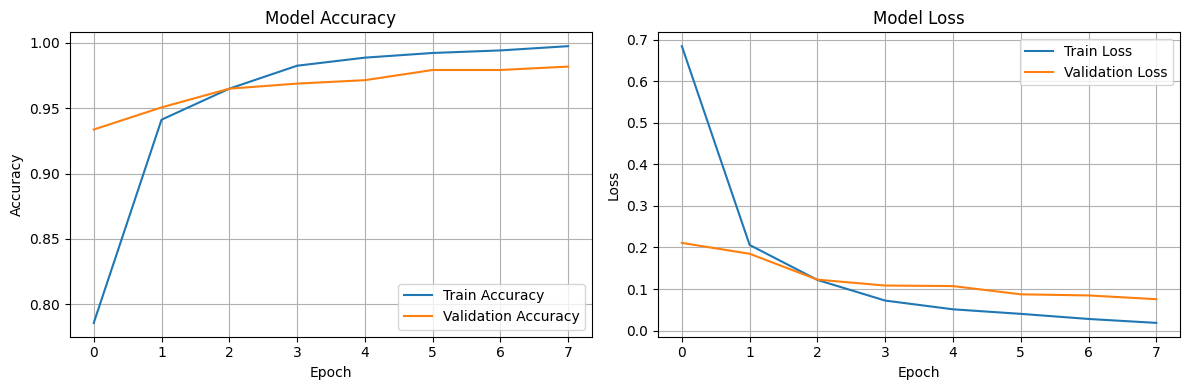

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [60]:
import zipfile
import os

zip_path = "/content/Wonders of World.zip"
extract_path = "/content/landmarks_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print("Subfolders:", os.listdir(extract_path))

Extraction complete.
Subfolders: ['machu_pichu', 'eiffel_tower', 'burj_khalifa', 'chichen_itza', 'pyramids_of_giza', 'stonehenge', 'taj_mahal', 'statue_of_liberty', 'venezuela_angel_falls', 'roman_colosseum', 'great_wall_of_china', '__MACOSX', 'Wonders of World', 'christ_the_reedemer']


In [61]:
data_dir = "/content/landmarks_data/Wonders of World"

In [66]:
model.save('landmark_detection_model.h5')

Saving collassium.jpg to collassium.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


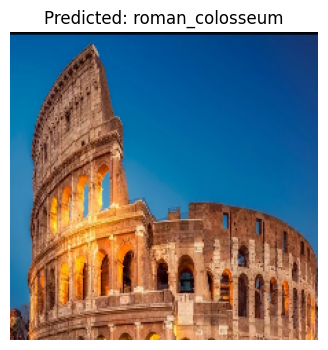

In [72]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model
from google.colab import files

uploaded = files.upload()

model = tf.keras.models.load_model("/content/landmark_detection_model.h5")

image_path = list(uploaded.keys())[0]

img = image.load_img(image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

pred = model.predict(img_array)

class_names = [
    'burj_khalifa', 'chichen_itza', 'christ_the_reedemer', 'eiffel_tower', 'great_wall_of_china',
    'machu_pichu', 'pyramids_of_giza', 'roman_colosseum', 'statue_of_liberty', 'stonehenge',
    'taj_mahal', 'venezuela_angel_falls'
]

predicted_class = class_names[np.argmax(pred)]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

In [73]:
from google.colab import drive
import tensorflow as tf

drive.mount('/content/drive')

model_save_path = '/content/drive/MyDrive/landmark_detection_model.h5'

model.save(model_save_path)

print(f"Model saved to {model_save_path}")

Mounted at /content/drive
Model saved to /content/drive/MyDrive/landmark_detection_model.h5
